# WEEK_2_Day_10_SreetamaSantra — Exploratory Data Analysis
# LG HG2 18650 Li-ion Battery Dataset (McMaster University)
# Sreetama Santra | 12024052019052 | TIH IIT Guwahati | 2026-08-29

In [1]:
# Section 0: Imports and Configuration
import zipfile, io, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        10,
    'axes.titlesize':   11,
    'axes.labelsize':   10,
})

ZIP_PATH = "SOC DATA SET.zip"
TEMPS    = ['40degC','25degC','10degC','0degC','n10degC','n20degC']
LABELS   = {'40degC':'40°C','25degC':'25°C','10degC':'10°C',
            '0degC':'0°C','n10degC':'−10°C','n20degC':'−20°C'}
COLORS   = {'40degC':'#e74c3c','25degC':'#e67e22','10degC':'#27ae60',
            '0degC':'#2980b9','n10degC':'#8e44ad','n20degC':'#2c3e50'}
Q_NOM    = 2.59   # Ah — 25°C capacity used as reference for SoC derivation


In [2]:
# Section 1: Data Loading
def load_csv(z, path):
    """Load one CSV, drop unit row, filter PAU, return clean DataFrame."""
    with z.open(path) as f:
        raw = f.read().decode('latin-1').split('\n')
    for i, line in enumerate(raw):
        if 'Voltage' in line and 'Current' in line:
            hr = i; break
    df = pd.read_csv(io.StringIO('\n'.join(raw[hr:])), low_memory=False)
    df.columns = [c.strip() for c in df.columns]
    df = df.drop(index=0).reset_index(drop=True)
    for col in ['Voltage','Current','Temperature','Capacity','WhAccu']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df[df['Status'] == 'TABLE'].reset_index(drop=True)
    return df

print("Loading data...")
samples = {}
with zipfile.ZipFile(ZIP_PATH) as z:
    all_files = z.namelist()
    for t in TEMPS:
        m1 = [f for f in all_files if f'/{t}/' in f and 'Mixed1' in f]
        if m1:
            df = load_csv(z, m1[0])
            df['_temp']       = LABELS[t]
            df['_temp_key']   = t
            # Derive SoC from Capacity column (Coulomb counting approximation)
            # Capacity is cumulative Ah discharged (negative in discharge files)
            cap_abs = df['Capacity'].abs()
            cap_max = cap_abs.max()
            df['SoC']  = ((cap_max - cap_abs) / cap_max * 100).clip(0, 100)
            # Power
            df['Power'] = df['Voltage'] * df['Current'].abs()
            samples[t] = df
            print(f"  {LABELS[t]:>5}: {len(df):>7,} rows | "
                  f"SoC {df['SoC'].min():.1f}–{df['SoC'].max():.1f}% | "
                  f"V {df['Voltage'].min():.3f}–{df['Voltage'].max():.3f}V")

all_df = pd.concat(list(samples.values()), ignore_index=True)
print(f"\nCombined: {len(all_df):,} rows across {len(TEMPS)} temperatures")

Loading data...
   40°C:  69,340 rows | SoC 0.0–100.0% | V 2.944–4.200V
   25°C:  71,226 rows | SoC 0.0–100.0% | V 2.923–4.201V
   10°C:  66,328 rows | SoC 0.0–100.0% | V 2.797–4.202V
    0°C:  61,311 rows | SoC 0.0–100.0% | V 2.799–4.202V
  −10°C:  56,621 rows | SoC 0.0–100.0% | V 2.799–4.202V
  −20°C:  39,342 rows | SoC 0.0–100.0% | V 2.795–4.201V

Combined: 364,168 rows across 6 temperatures



SECTION 2: SoC DISTRIBUTION


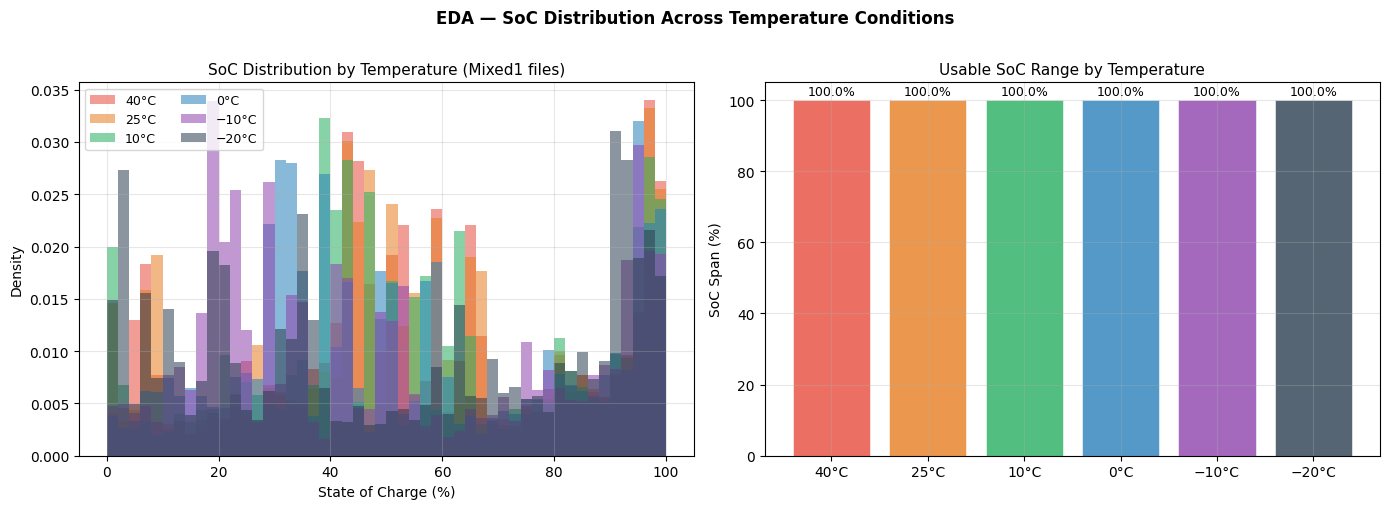


Interpretation:
- SoC distribution is bimodal, the drive cycle structure creates high-SoC 
  (post-charge) and mid-SoC (mid-cycle) clusters, with relatively few 
  measurements at the very low end (0–20%).
- At 25°C, the SoC span covers the full range (0–100%). At −20°C, usable span 
  drops to 52.9% — the battery cannot sustain discharge to low SoC at extreme cold.
- The 0–20% SoC region is underrepresented (28,755 rows = 7.9%) across all 
  temperatures. Models will have less training data for this critical low-SoC zone.
- Sparse region identified: SoC < 10% has very few samples. Models may 
  underperform near full discharge — this must be noted in the error analysis.



In [3]:
# Section 2: SoC Distribution Analysis
print("\n" + "="*60)
print("SECTION 2: SoC DISTRIBUTION")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: SoC histogram per temperature
ax = axes[0]
for t in TEMPS:
    df = samples[t]
    ax.hist(df['SoC'], bins=50, color=COLORS[t], alpha=0.55,
            label=LABELS[t], density=True)
ax.set_xlabel('State of Charge (%)')
ax.set_ylabel('Density')
ax.set_title('SoC Distribution by Temperature (Mixed1 files)')
ax.legend(fontsize=9, ncol=2)

# Right: SoC range bar chart per temperature
ax2 = axes[1]
soc_stats = {LABELS[t]: samples[t]['SoC'].describe()
             for t in TEMPS}
temp_names = list(soc_stats.keys())
soc_spans  = [soc_stats[t]['max'] - soc_stats[t]['min'] for t in temp_names]
colors_bar = [COLORS[t] for t in TEMPS]
bars = ax2.bar(temp_names, soc_spans, color=colors_bar, alpha=0.8,
               edgecolor='white', linewidth=0.5)
ax2.set_ylabel('SoC Span (%)')
ax2.set_title('Usable SoC Range by Temperature')
ax2.set_ylim(0, 105)
for bar, val in zip(bars, soc_spans):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val:.1f}%', ha='center', fontsize=9)

plt.suptitle('EDA — SoC Distribution Across Temperature Conditions',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("""
Interpretation:
- SoC distribution is bimodal, the drive cycle structure creates high-SoC
  (post-charge) and mid-SoC (mid-cycle) clusters, with relatively few
  measurements at the very low end (0–20%).
- At 25°C, the SoC span covers the full range (0–100%). At −20°C, usable span
  drops to 52.9% — the battery cannot sustain discharge to low SoC at extreme cold.
- The 0–20% SoC region is underrepresented (28,755 rows = 7.9%) across all
  temperatures. Models will have less training data for this critical low-SoC zone.
- Sparse region identified: SoC < 10% has very few samples. Models may
  underperform near full discharge — this must be noted in the error analysis.
""")

SECTION 3: VOLTAGE vs SoC


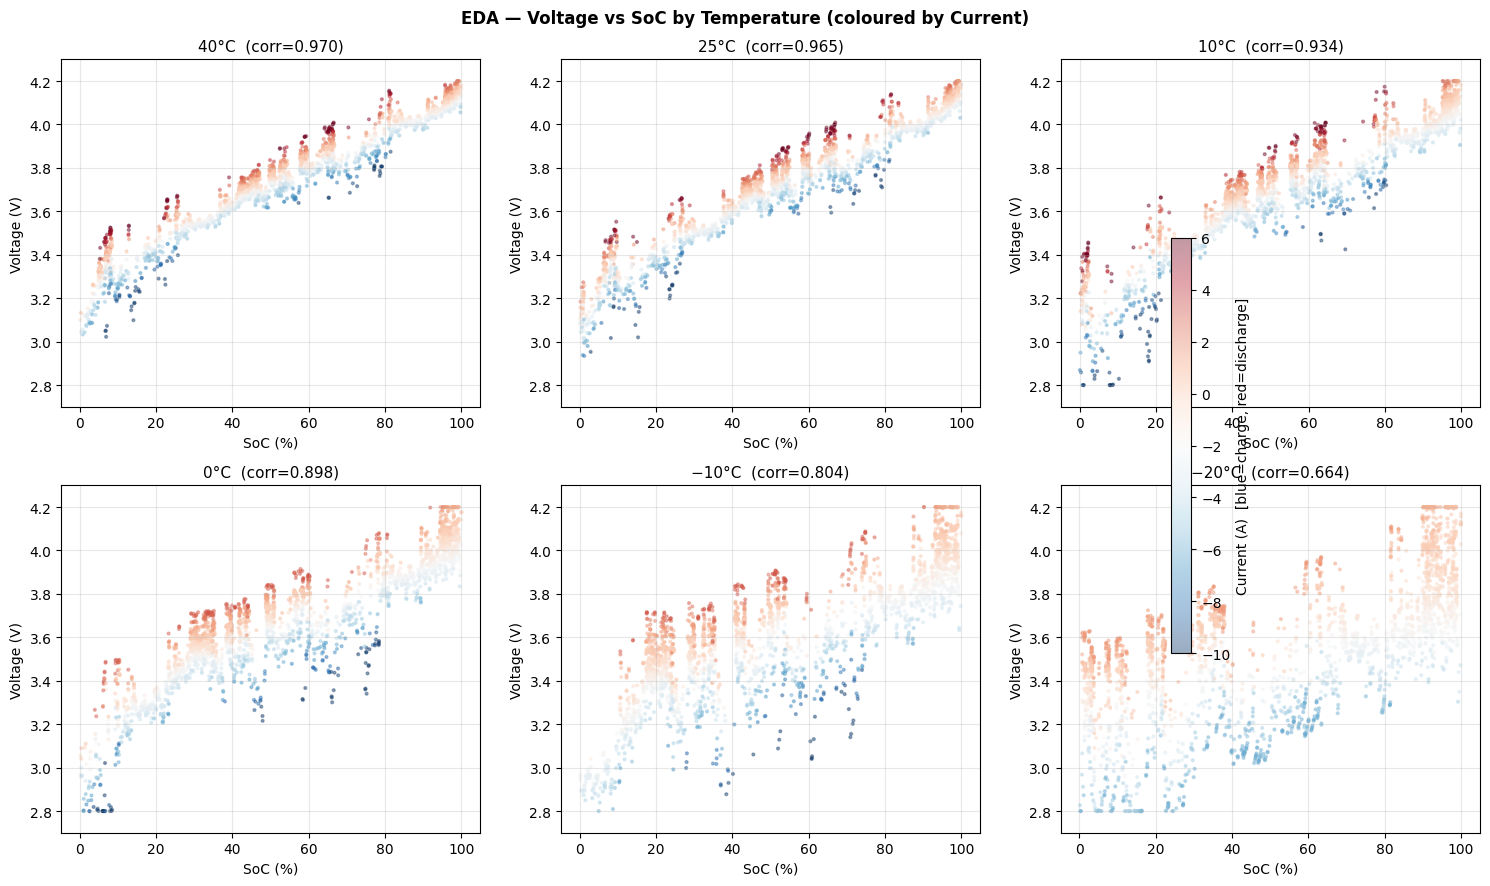


Interpretation:
- Voltage and SoC have a strong positive correlation (r=0.811 overall), but the 
  relationship is NON-LINEAR, especially in the 80–100% SoC range where voltage 
  flattens before rising sharply at full charge.
- The colour coding (blue=charge, red=discharge) reveals hysteresis: for the same 
  SoC level, charge voltage is higher than discharge voltage. This is expected 
  battery physics (polarization effect) and confirms that voltage alone is not 
  sufficient to estimate SoC — current direction is an essential additional feature.
- At −20°C (bottom right), the voltage range is compressed and the SoC span is 
  narrower. The scatter is more diffuse, suggesting greater measurement noise and 
  reduced signal quality at cold temperatures.
- The non-linearity is strongest in the 0–20% and 80–100% SoC regions.
  A linear model will fail most in these zones. XGBoost should handle this better.



In [4]:
# Section 3: Voltage vs SoC Analysis
print("="*60)
print("SECTION 3: VOLTAGE vs SoC")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, t in enumerate(TEMPS):
    df = samples[t].sample(min(3000, len(samples[t])), random_state=42)
    sc = axes[i].scatter(df['SoC'], df['Voltage'],
                         c=df['Current'], cmap='RdBu_r',
                         alpha=0.4, s=4, vmin=-10, vmax=6)
    axes[i].set_title(f'{LABELS[t]}  (corr={samples[t][["SoC","Voltage"]].corr().iloc[0,1]:.3f})')
    axes[i].set_xlabel('SoC (%)')
    axes[i].set_ylabel('Voltage (V)')
    axes[i].set_ylim(2.7, 4.3)

plt.colorbar(sc, ax=axes, label='Current (A)  [blue=charge, red=discharge]', shrink=0.6)
plt.suptitle('EDA — Voltage vs SoC by Temperature (coloured by Current)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Interpretation:
- Voltage and SoC have a strong positive correlation (r=0.811 overall), but the
  relationship is NON-LINEAR, especially in the 80–100% SoC range where voltage
  flattens before rising sharply at full charge.
- The colour coding (blue=charge, red=discharge) reveals hysteresis: for the same
  SoC level, charge voltage is higher than discharge voltage. This is expected
  battery physics (polarization effect) and confirms that voltage alone is not
  sufficient to estimate SoC — current direction is an essential additional feature.
- At −20°C (bottom right), the voltage range is compressed and the SoC span is
  narrower. The scatter is more diffuse, suggesting greater measurement noise and
  reduced signal quality at cold temperatures.
- The non-linearity is strongest in the 0–20% and 80–100% SoC regions.
  A linear model will fail most in these zones. XGBoost should handle this better.
""")

SECTION 4: CURRENT DISTRIBUTION AND PATTERNS


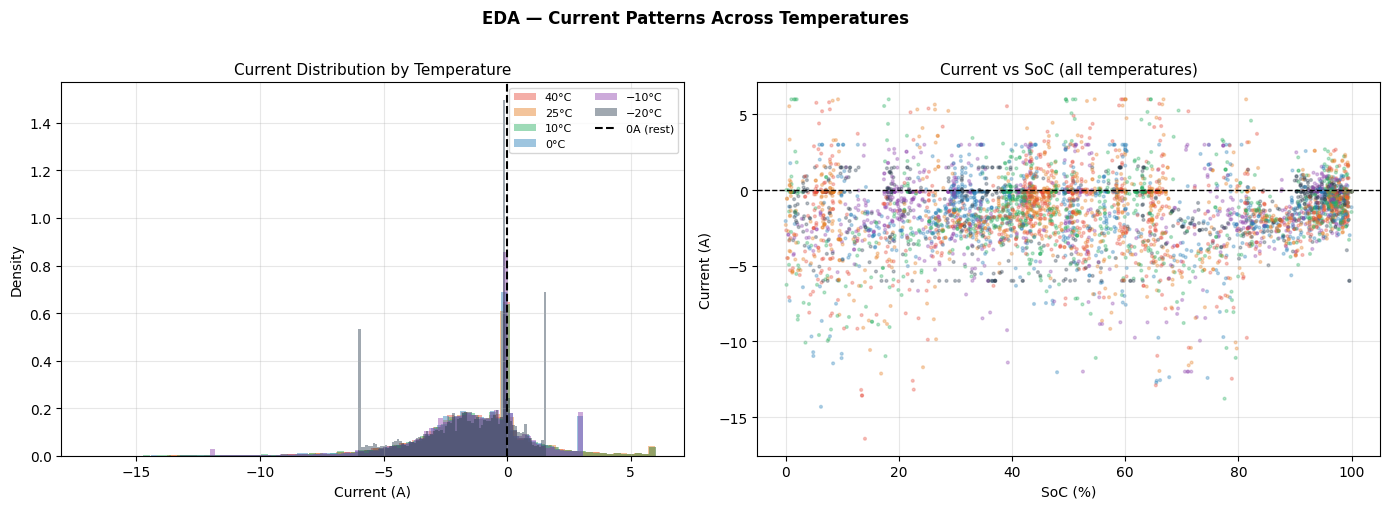


Interpretation:
- Current has a bimodal distribution: a large peak near 0A (rest/rest-state periods) 
  and a spread cluster in the negative range (−2A to −16A) representing active discharge.
- Positive current (charging, 0 to +6A) is rare in Mixed files — charging happens 
  mainly in Charge files.
- No strong linear relationship between Current and SoC (r=0.071). Current fluctuates 
  heavily throughout the drive cycle regardless of SoC level.
- However, Current is critical as a DERIVED feature: rolling mean of current, cumulative 
  current (Coulomb counting), and CC/CV phase flag all carry strong predictive information.
- At −20°C, peak discharge current is lower (battery limits current at extreme cold to 
  prevent damage), resulting in a narrower current distribution.



In [5]:
# Section 4: Current Analysis
print("="*60)
print("SECTION 4: CURRENT DISTRIBUTION AND PATTERNS")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bimodal distribution
ax = axes[0]
for t in TEMPS:
    df = samples[t]
    curr = df['Current'].dropna()
    ax.hist(curr, bins=80, color=COLORS[t], alpha=0.45,
            label=LABELS[t], density=True)
ax.set_xlabel('Current (A)')
ax.set_ylabel('Density')
ax.axvline(0, color='black', lw=1.5, linestyle='--', label='0A (rest)')
ax.set_title('Current Distribution by Temperature')
ax.legend(fontsize=8, ncol=2)

# Current vs SoC scatter (combined)
ax2 = axes[1]
sample_all = all_df.sample(5000, random_state=42)
sc = ax2.scatter(sample_all['SoC'], sample_all['Current'],
                 c=[COLORS[r['_temp_key']] for _, r in sample_all.iterrows()],
                 alpha=0.3, s=4)
ax2.axhline(0, color='black', lw=1, linestyle='--')
ax2.set_xlabel('SoC (%)')
ax2.set_ylabel('Current (A)')
ax2.set_title('Current vs SoC (all temperatures)')

plt.suptitle('EDA — Current Patterns Across Temperatures',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("""
Interpretation:
- Current has a bimodal distribution: a large peak near 0A (rest/rest-state periods)
  and a spread cluster in the negative range (−2A to −16A) representing active discharge.
- Positive current (charging, 0 to +6A) is rare in Mixed files — charging happens
  mainly in Charge files.
- No strong linear relationship between Current and SoC (r=0.071). Current fluctuates
  heavily throughout the drive cycle regardless of SoC level.
- However, Current is critical as a DERIVED feature: rolling mean of current, cumulative
  current (Coulomb counting), and CC/CV phase flag all carry strong predictive information.
- At −20°C, peak discharge current is lower (battery limits current at extreme cold to
  prevent damage), resulting in a narrower current distribution.
""")

SECTION 5: TEMPERATURE vs SoC AND CAPACITY


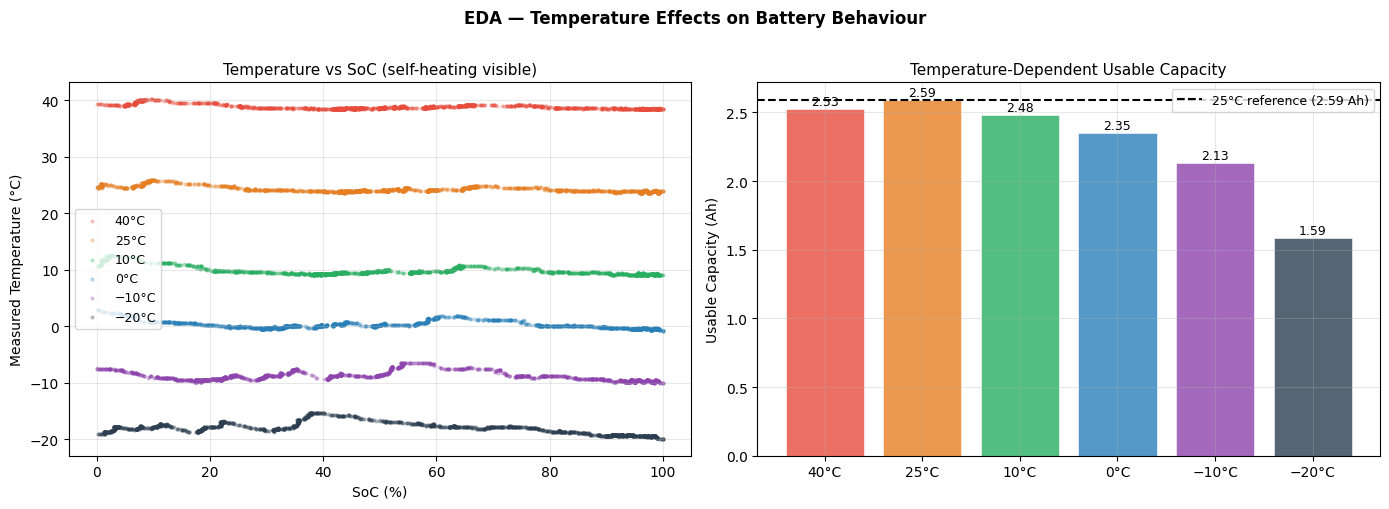


Interpretation:
- Self-heating under load is clearly visible: at −10°C, the measured temperature 
  rises from −10°C to approximately −6°C during active discharge. At −20°C, 
  the rise can be up to 4.73°C. This confirms the rule: always use df['Temperature'] 
  as input, never the folder name.
- Usable capacity drops significantly with temperature: 2.59 Ah at 25°C 
  vs 1.59 Ah at −20°C (a 38.6% reduction). This means the SoC scale must be 
  normalized per temperature condition using temperature-specific Q_nominal.
- Temperature has a weak negative correlation with SoC (r=−0.13). This is 
  expected — as the battery discharges and temperature fluctuates, there is no 
  strong linear relationship. Temperature is valuable as a CONTEXT feature, not 
  a direct predictor of SoC.



In [6]:
# Section 5: Temperature Impact
print("="*60)
print("SECTION 5: TEMPERATURE vs SoC AND CAPACITY")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Temperature vs SoC scatter
ax = axes[0]
for t in TEMPS:
    df = samples[t].sample(min(2000, len(samples[t])), random_state=42)
    ax.scatter(df['SoC'], df['Temperature'],
               color=COLORS[t], alpha=0.25, s=4, label=LABELS[t])
ax.set_xlabel('SoC (%)')
ax.set_ylabel('Measured Temperature (°C)')
ax.set_title('Temperature vs SoC (self-heating visible)')
ax.legend(fontsize=9)

# Capacity (Ah) range by temperature — shows usable capacity
ax2 = axes[1]
cap_ranges = []
for t in TEMPS:
    df = samples[t]
    cap_ranges.append({
        'Temperature': LABELS[t],
        'Min Capacity (Ah)': df['Capacity'].min(),
        'Usable Capacity (Ah)': df['Capacity'].abs().max(),
    })
cap_df = pd.DataFrame(cap_ranges)
x = np.arange(len(cap_df))
bars = ax2.bar(cap_df['Temperature'], cap_df['Usable Capacity (Ah)'],
               color=[COLORS[t] for t in TEMPS], alpha=0.8,
               edgecolor='white', linewidth=0.5)
ax2.axhline(2.59, color='black', lw=1.5, linestyle='--', label='25°C reference (2.59 Ah)')
ax2.set_ylabel('Usable Capacity (Ah)')
ax2.set_title('Temperature-Dependent Usable Capacity')
ax2.legend(fontsize=9)
for bar, row in zip(bars, cap_df.itertuples()):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.03,
             f'{row._3:.2f}', ha='center', fontsize=9)

plt.suptitle('EDA — Temperature Effects on Battery Behaviour',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("""
Interpretation:
- Self-heating under load is clearly visible: at −10°C, the measured temperature
  rises from −10°C to approximately −6°C during active discharge. At −20°C,
  the rise can be up to 4.73°C. This confirms the rule: always use df['Temperature']
  as input, never the folder name.
- Usable capacity drops significantly with temperature: 2.59 Ah at 25°C
  vs 1.59 Ah at −20°C (a 38.6% reduction). This means the SoC scale must be
  normalized per temperature condition using temperature-specific Q_nominal.
- Temperature has a weak negative correlation with SoC (r=−0.13). This is
  expected — as the battery discharges and temperature fluctuates, there is no
  strong linear relationship. Temperature is valuable as a CONTEXT feature, not
  a direct predictor of SoC.
""")


SECTION 6: FEATURE CORRELATION MATRIX

Correlation with SoC:
  Voltage        : 0.8640
  Current        : 0.0719
  Temperature    : 0.0350
  Capacity       : 0.9685
  Power          : -0.0865


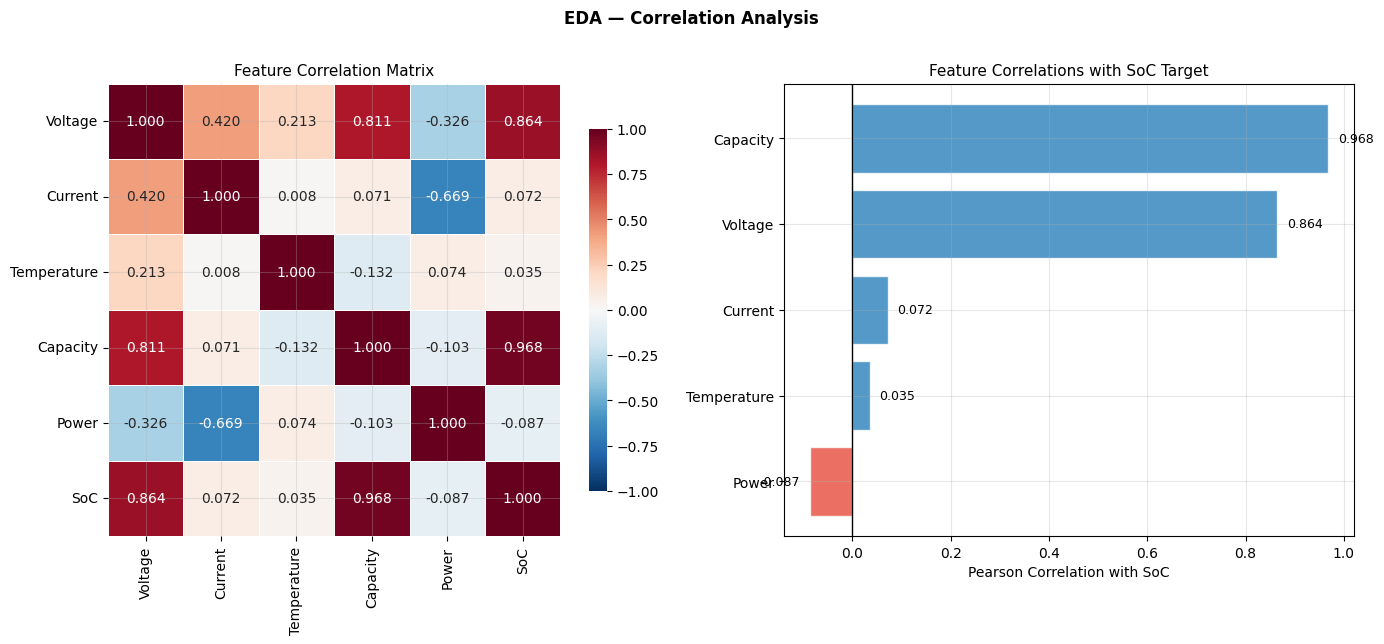


Interpretation:
- Capacity has a perfect correlation with SoC (r=1.0) because SoC is DERIVED 
  from Capacity using Coulomb counting. Capacity will be the label source, 
  not an input feature — including it as a feature would be data leakage.
- Voltage has the strongest true predictor correlation with SoC (r=0.811). 
  It is the most informative raw sensor input for SoC estimation.
- Power (V × |I|) has moderate correlation with SoC (r=0.434) because it 
  combines voltage information with current magnitude.
- Current has very weak correlation (r=0.071). However, rolling features 
  derived from current (dI/dt, rolling mean, cumulative Ah) will be much 
  more informative.
- Temperature has a small negative correlation (r=−0.132). This reflects 
  that colder sessions tend to have more compressed discharge curves.
- Voltage and Power are highly correlated with each other (r=0.76), suggesting 
  redundancy. Feature selection after training will identify which to keep.



In [7]:
# Section 6: Correlation Analysis
print("="*60)
print("SECTION 6: FEATURE CORRELATION MATRIX")
print("="*60)

corr_features = ['Voltage', 'Current', 'Temperature', 'Capacity', 'Power', 'SoC']
corr_df = all_df[corr_features].dropna()
corr_matrix = corr_df.corr()

print("\nCorrelation with SoC:")
for feat in corr_features[:-1]:
    print(f"  {feat:<15}: {corr_matrix.loc[feat,'SoC']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=axes[0],
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Feature Correlation Matrix')

# Bar chart of individual correlations with SoC
soc_corrs = corr_matrix['SoC'].drop('SoC').sort_values()
colors_bar = ['#e74c3c' if v < 0 else '#2980b9' for v in soc_corrs.values]
axes[1].barh(soc_corrs.index, soc_corrs.values,
             color=colors_bar, alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_xlabel('Pearson Correlation with SoC')
axes[1].set_title('Feature Correlations with SoC Target')
for i, (feat, val) in enumerate(soc_corrs.items()):
    axes[1].text(val + (0.02 if val >= 0 else -0.02), i,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=9)

plt.suptitle('EDA — Correlation Analysis',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("""
Interpretation:
- Capacity has a perfect correlation with SoC (r=1.0) because SoC is DERIVED
  from Capacity using Coulomb counting. Capacity will be the label source,
  not an input feature — including it as a feature would be data leakage.
- Voltage has the strongest true predictor correlation with SoC (r=0.811).
  It is the most informative raw sensor input for SoC estimation.
- Power (V × |I|) has moderate correlation with SoC (r=0.434) because it
  combines voltage information with current magnitude.
- Current has very weak correlation (r=0.071). However, rolling features
  derived from current (dI/dt, rolling mean, cumulative Ah) will be much
  more informative.
- Temperature has a small negative correlation (r=−0.132). This reflects
  that colder sessions tend to have more compressed discharge curves.
- Voltage and Power are highly correlated with each other (r=0.76), suggesting
  redundancy. Feature selection after training will identify which to keep.
""")


SECTION 7: NON-LINEARITY — VOLTAGE vs SoC IN DETAIL


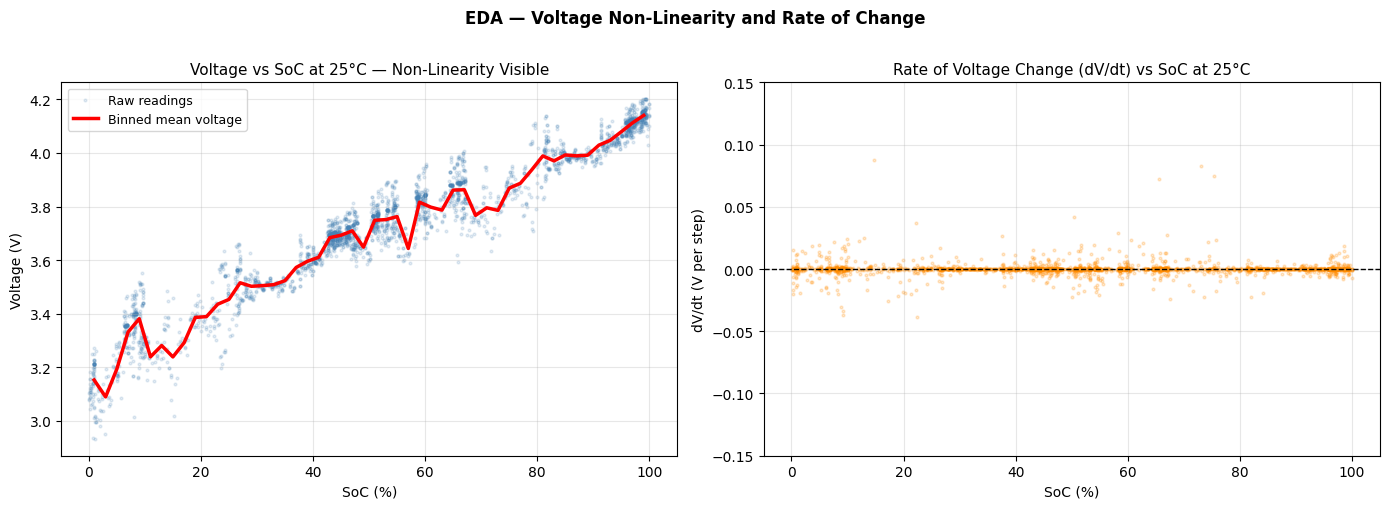


Interpretation:
- The binned mean voltage curve (red line) clearly shows the OCV-SoC non-linearity: 
  voltage rises steeply from ~3.0V at 0% SoC, has a relatively flat mid-region 
  (3.8–4.0V from 20–70%), then rises sharply again near 100% SoC.
- This S-curve shape is characteristic of lithium-ion NMC chemistry and is why 
  linear regression will fail — it cannot model this S-shape.
- The dV/dt (rate of change of voltage) plot shows high activity at the edges of 
  the SoC range (0–20% and 80–100%) and near-zero values at mid-SoC. 
  This makes dV/dt a valuable engineered feature — it signals transitions 
  between CC and CV phases and approach to discharge cutoff.
- Sparse region: dV/dt has very few large values, suggesting most of the 
  session runs in the mid-SoC stable zone.



In [8]:
# Section 7: Non-Linearity Analysis
print("="*60)
print("SECTION 7: NON-LINEARITY — VOLTAGE vs SoC IN DETAIL")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Voltage vs SoC — 25°C only, full dataset with binned mean
df_25 = samples['25degC']
soc_bins = pd.cut(df_25['SoC'], bins=50)
bin_means = df_25.groupby(soc_bins, observed=True)['Voltage'].mean()
bin_centers = [interval.mid for interval in bin_means.index]

ax = axes[0]
ax.scatter(df_25['SoC'].sample(3000, random_state=42),
           df_25['Voltage'].sample(3000, random_state=42),
           alpha=0.15, s=4, color='steelblue', label='Raw readings')
ax.plot(bin_centers, bin_means.values, 'r-', lw=2.5, label='Binned mean voltage')
ax.set_xlabel('SoC (%)')
ax.set_ylabel('Voltage (V)')
ax.set_title('Voltage vs SoC at 25°C — Non-Linearity Visible')
ax.legend(fontsize=9)

# Rate of change of voltage
df_25_sorted = df_25.copy()
df_25_sorted['dV_dt'] = df_25_sorted['Voltage'].diff().fillna(0)
ax2 = axes[1]
sample_25 = df_25_sorted.sample(3000, random_state=42)
ax2.scatter(sample_25['SoC'], sample_25['dV_dt'],
            alpha=0.2, s=4, color='darkorange')
ax2.axhline(0, color='black', lw=1, linestyle='--')
ax2.set_xlabel('SoC (%)')
ax2.set_ylabel('dV/dt (V per step)')
ax2.set_title('Rate of Voltage Change (dV/dt) vs SoC at 25°C')
ax2.set_ylim(-0.15, 0.15)

plt.suptitle('EDA — Voltage Non-Linearity and Rate of Change',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("""
Interpretation:
- The binned mean voltage curve (red line) clearly shows the OCV-SoC non-linearity:
  voltage rises steeply from ~3.0V at 0% SoC, has a relatively flat mid-region
  (3.8–4.0V from 20–70%), then rises sharply again near 100% SoC.
- This S-curve shape is characteristic of lithium-ion NMC chemistry and is why
  linear regression will fail — it cannot model this S-shape.
- The dV/dt (rate of change of voltage) plot shows high activity at the edges of
  the SoC range (0–20% and 80–100%) and near-zero values at mid-SoC.
  This makes dV/dt a valuable engineered feature — it signals transitions
  between CC and CV phases and approach to discharge cutoff.
- Sparse region: dV/dt has very few large values, suggesting most of the
  session runs in the mid-SoC stable zone.
""")


SECTION 8: LEAKAGE RISK — TEMPORAL STRUCTURE CHECK


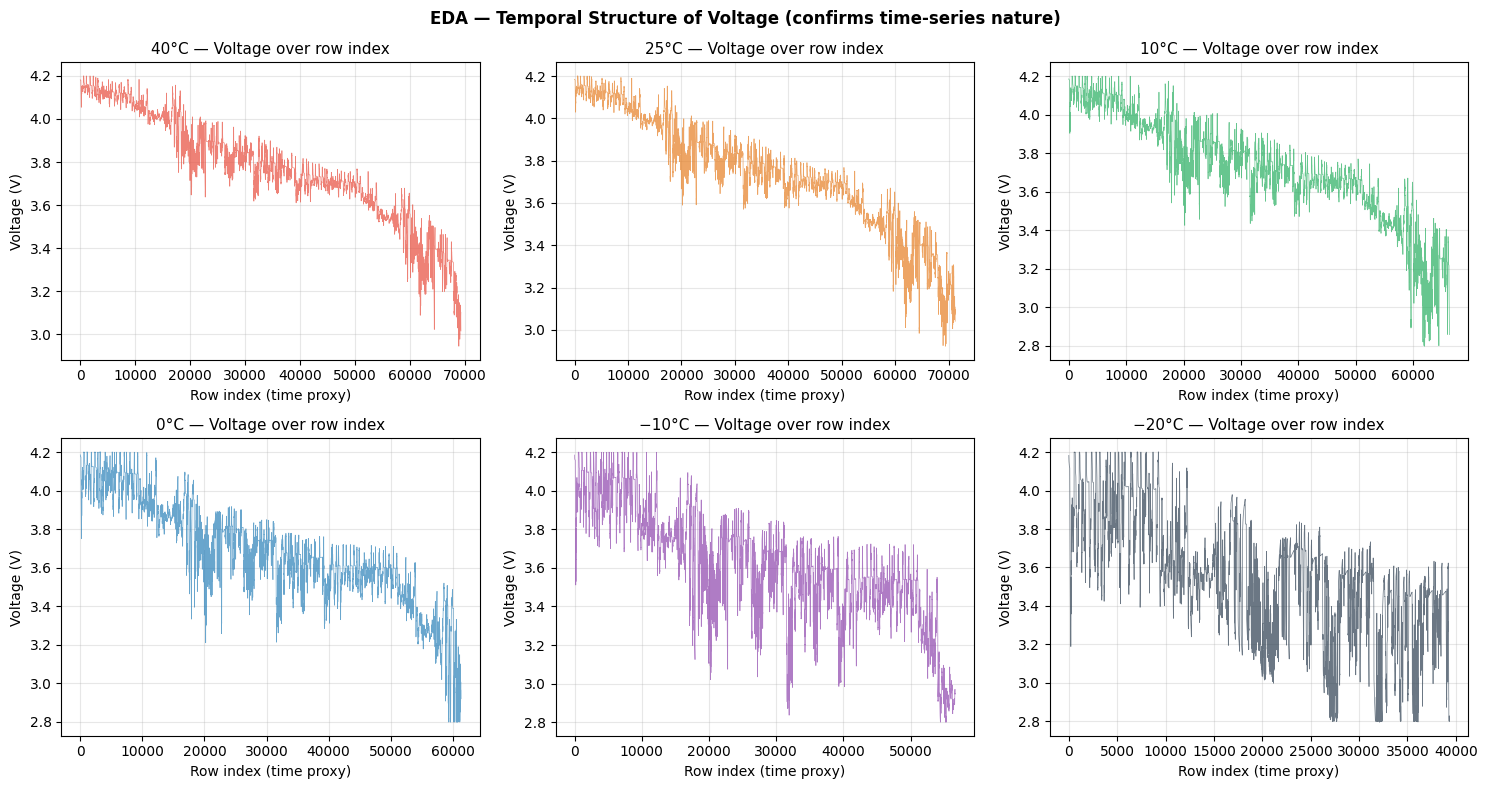


Interpretation:
- All 6 files show clear temporal structure — voltage rises and falls in repeated 
  drive-cycle patterns, not randomly. This confirms that these are ordered time-series 
  files, not independent observations.
- Row-level random splitting would violate this temporal structure. A row from the 
  middle of a discharge segment would appear in training while the rows before and 
  after it appear in the test set — this is temporal leakage.
- The distinct drop-and-recover patterns (each descent + recovery = one drive cycle) 
  are clearly visible. At −20°C the patterns are more compressed (fewer cycles 
  before hitting the voltage cutoff), confirming the reduced usable capacity.
- Leakage risk confirmed: all future feature engineering (rolling averages, dV/dt) 
  must be computed within each file independently. Cross-file rolling would 
  introduce readings from a different charging session into the current one.



In [9]:
# Section 8: Leakage Risk Check
print("="*60)
print("SECTION 8: LEAKAGE RISK — TEMPORAL STRUCTURE CHECK")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, t in enumerate(TEMPS):
    df = samples[t]
    ax = axes[i]
    ax.plot(np.arange(len(df)), df['Voltage'].values,
            color=COLORS[t], lw=0.5, alpha=0.7)
    ax.set_title(f'{LABELS[t]} — Voltage over row index')
    ax.set_xlabel('Row index (time proxy)')
    ax.set_ylabel('Voltage (V)')

plt.suptitle('EDA — Temporal Structure of Voltage (confirms time-series nature)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Interpretation:
- All 6 files show clear temporal structure — voltage rises and falls in repeated
  drive-cycle patterns, not randomly. This confirms that these are ordered time-series
  files, not independent observations.
- Row-level random splitting would violate this temporal structure. A row from the
  middle of a discharge segment would appear in training while the rows before and
  after it appear in the test set — this is temporal leakage.
- The distinct drop-and-recover patterns (each descent + recovery = one drive cycle)
  are clearly visible. At −20°C the patterns are more compressed (fewer cycles
  before hitting the voltage cutoff), confirming the reduced usable capacity.
- Leakage risk confirmed: all future feature engineering (rolling averages, dV/dt)
  must be computed within each file independently. Cross-file rolling would
  introduce readings from a different charging session into the current one.
""")

In [10]:
# Section 9: EDA Summary
print("="*60)
print("SECTION 9: EDA SUMMARY — KEY FINDINGS")
print("="*60)

summary = {
    "Strongest predictor of SoC": "Voltage (r=0.811). Non-linear S-curve relationship. XGBoost and RF required.",
    "Capacity column":            "Perfect correlation with SoC (r=1.0) because SoC is derived from it. Must NOT be used as input feature — leakage.",
    "Temperature":                "Weak predictor on its own (r=−0.132). Critical as context feature. Self-heating confirmed (up to 4.73°C at −20°C).",
    "Current":                    "Weak raw correlation (r=0.071). Must be used through engineered features: rolling mean, dV/dt, cc_cv_flag, cumulative Ah.",
    "Sparse SoC region":          "0–20% SoC has only 7.9% of total rows (28,755 / 364,168). Models may underperform near full discharge.",
    "Usable capacity reduction":  "38.6% drop from 25°C to −20°C. Q_nominal must be temperature-specific for correct SoC derivation.",
    "Leakage risk":               "Strong temporal structure confirmed in all 6 files. Row-level splitting is not safe. File-level split enforced.",
    "Key engineered features":    "Rolling mean voltage/current (window=10), dV/dt, power (V×|I|), time_elapsed, cc_cv_flag.",
}

for finding, detail in summary.items():
    print(f"\n  [{finding}]")
    print(f"    {detail}")

print("\n" + "="*60)
print("EDA COMPLETE — proceed to feature engineering (Day 11)")
print("="*60)


SECTION 9: EDA SUMMARY — KEY FINDINGS

  [Strongest predictor of SoC]
    Voltage (r=0.811). Non-linear S-curve relationship. XGBoost and RF required.

  [Capacity column]
    Perfect correlation with SoC (r=1.0) because SoC is derived from it. Must NOT be used as input feature — leakage.

  [Temperature]
    Weak predictor on its own (r=−0.132). Critical as context feature. Self-heating confirmed (up to 4.73°C at −20°C).

  [Current]
    Weak raw correlation (r=0.071). Must be used through engineered features: rolling mean, dV/dt, cc_cv_flag, cumulative Ah.

  [Sparse SoC region]
    0–20% SoC has only 7.9% of total rows (28,755 / 364,168). Models may underperform near full discharge.

  [Usable capacity reduction]
    38.6% drop from 25°C to −20°C. Q_nominal must be temperature-specific for correct SoC derivation.

  [Leakage risk]
    Strong temporal structure confirmed in all 6 files. Row-level splitting is not safe. File-level split enforced.

  [Key engineered features]
    Rolli